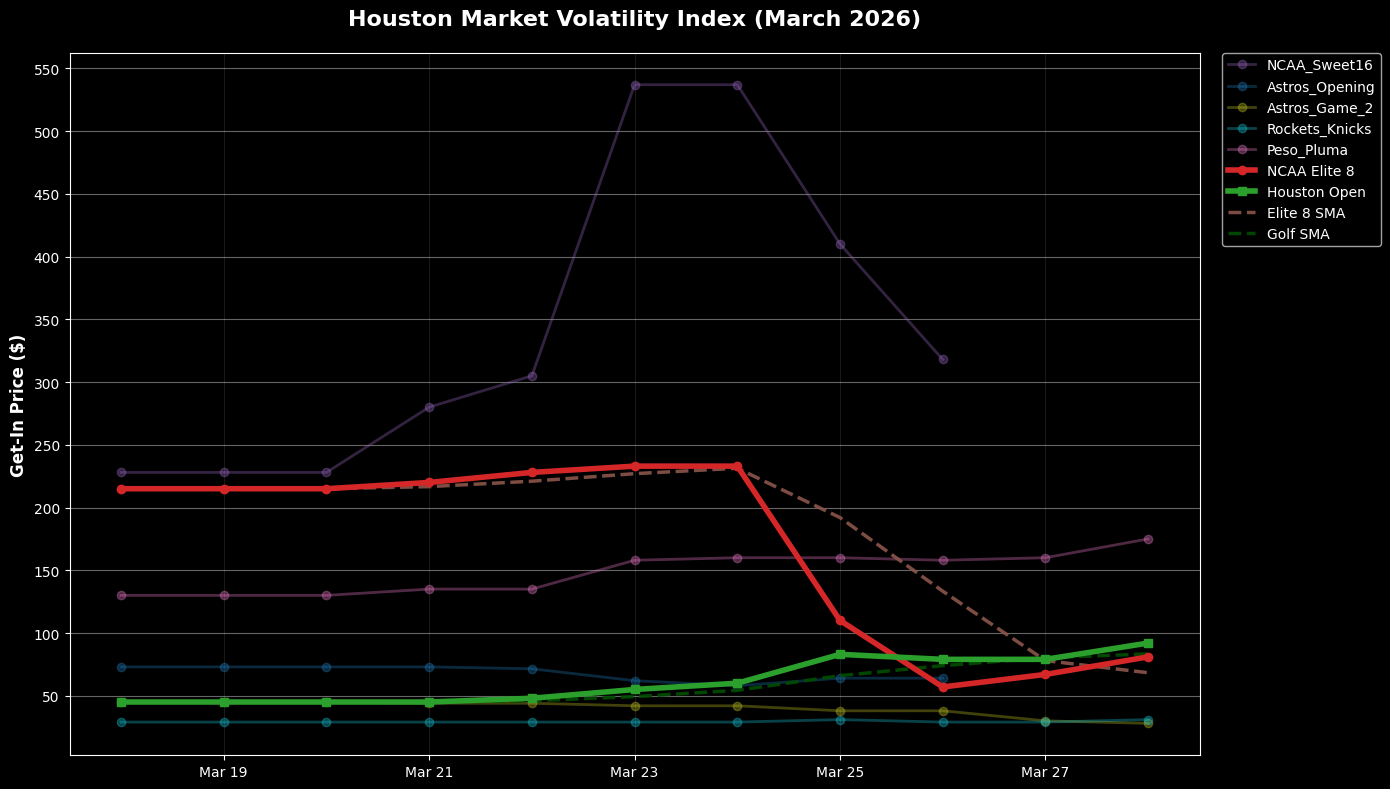


                               🚀 HOUSTON MARKET AUDIT: FINAL PUSH                              
EVENT NAME             | START    | CURRENT        | 3-DAY SMA    | TOTAL CHG
-----------------------------------------------------------------------------------------------
NCAA_Sweet16           | $228     | $318           |  --          |    39.5% 📈
NCAA_Elite8            | $215     | $81            | $68.33       |   -62.3% 📉
Astros_Opening         | $73      | $64            |  --          |   -12.3% 📉
Astros_Game_2          | $45      | $28            |  --          |   -37.8% 📉
Rockets_Knicks         | $29      | $31            |  --          |     6.9% 📈
Peso_Pluma             | $130     | $175           |  --          |    34.6% 📈
Houston_Open           | $45      | $92            | $83.33       |   104.4% 📈


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

def run_houston_market_final_push():
    # 1. LIVE DATA ENTRY (Verified March 28, 2026)
    houston_trends = {
        'NCAA_Sweet16':   [228, 228, 228, 280, 305, 537, 537, 410, 318, None, None],
        'NCAA_Elite8':    [215, 215, 215, 220, 228, 233, 233, 110, 57, 67, 81],
        'Astros_Opening': [73, 73, 73, 73, 71.5, 62, 58, 64, 64, None, None],
        'Astros_Game_2':  [45, 45, 45, 44, 44, 42, 42, 38, 38, 30, 28],
        'Rockets_Knicks': [29, 29, 29, 29, 29, 29, 29, 31, 29, 29, 31],
        'Peso_Pluma':     [130, 130, 130, 135, 135, 158, 160, 160, 158, 160, 175],
        'Houston_Open':   [45, 45, 45, 45, 48, 55, 60, 83, 79, 79, 92]
    }

    # 2. DATE ALIGNMENT
    today = datetime(2026, 3, 28)
    data_length = len(houston_trends['NCAA_Elite8'])
    date_list = [(today - timedelta(days=i)).strftime("%Y-%m-%d") for i in range(data_length - 1, -1, -1)]
    df = pd.DataFrame(houston_trends, index=pd.to_datetime(date_list))

    # 3. SMA CALCULATIONS
    df['Elite8_Trend'] = df['NCAA_Elite8'].rolling(window=3).mean()
    df['Golf_Trend']   = df['Houston_Open'].rolling(window=3).mean()

    # --- VISUALIZATION (VIBRANT COLORS) ---
    plt.style.use('seaborn-v0_8-muted') # Cleaner, more modern style
    fig, ax = plt.subplots(figsize=(14, 8))

    # Background Events (Using slightly higher alpha and distinct colors)
    bg_colors = ['#9467bd', '#1f77b4', '#bcbd22', '#17becf', '#e377c2']
    bg_events = ['NCAA_Sweet16', 'Astros_Opening', 'Astros_Game_2', 'Rockets_Knicks', 'Peso_Pluma']

    for event, color in zip(bg_events, bg_colors):
        valid = df[event].dropna()
        ax.plot(valid.index, valid.values, marker='o', alpha=0.35, linewidth=2, label=event, color=color)

    # Highlighted Target Events (Bold, Vivid Colors)
    ax.plot(df.index, df['NCAA_Elite8'], marker='o', color='#d62728', linewidth=4, label='NCAA Elite 8', zorder=5)
    ax.plot(df.index, df['Houston_Open'], marker='s', color='#2ca02c', linewidth=4, label='Houston Open', zorder=5)

    # Trendlines (White-glow effect using dark dashed lines)
    ax.plot(df.index, df['Elite8_Trend'], color='#8c564b', linestyle='--', linewidth=2.5, alpha=0.9, label='Elite 8 SMA')
    ax.plot(df.index, df['Golf_Trend'], color='#004d00', linestyle='--', linewidth=2.5, alpha=0.9, label='Golf SMA')

    # Y-AXIS 50-INCREMENTS
    ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.grid(True, which='major', axis='y', alpha=0.4, linestyle='-')
    ax.grid(True, which='major', axis='x', alpha=0.1)

    ax.set_title('Houston Market Volatility Index (March 2026)', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Get-In Price ($)', fontsize=12, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.savefig('houston_market_analysis.png', dpi=300) # Higher DPI for GitHub clarity
    plt.show()

    # --- TERMINAL REPORT (FORCE ALL ROWS) ---
    print("\n" + "🚀 HOUSTON MARKET AUDIT: FINAL PUSH".center(95))
    print("=" * 95)
    print(f"{'EVENT NAME':<22} | {'START':<8} | {'CURRENT':<14} | {'3-DAY SMA':<12} | {'TOTAL CHG'}")
    print("-" * 95)

    # Iterate through all keys to ensure none are skipped
    for event in houston_trends.keys():
        prices = df[event].dropna().values
        if len(prices) == 0: continue

        p_start, p_last = prices[0], prices[-1]

        # SMA Logic
        ma_col = {'NCAA_Elite8': 'Elite8_Trend', 'Houston_Open': 'Golf_Trend'}.get(event)
        if ma_col and not np.isnan(df[ma_col].iloc[-1]):
            ma_val = f"${df[ma_col].iloc[-1]:.2f}"
        else:
            ma_val = " -- "

        # Dynamic Status
        is_final = " (Final)" if df[event].iloc[-1] is None else ""
        current_display = f"${p_last:.0f}{is_final}"

        # Change %
        chg = ((p_last - p_start) / p_start) * 100
        icon = "📈" if chg > 0 else "📉"
        chg_display = f"{chg:>7.1f}% {icon}"

        print(f"{event:<22} | ${p_start:<7.0f} | {current_display:<14} | {ma_val:<12} | {chg_display}")

    print("=" * 95)

run_houston_market_final_push()